# ek_pca_t2
RobustScaler → window statistics → PCA → T² + Q anomaly scoring · event F0.5 tuning

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/Colab Notebooks/sentinel
!pip install -e .

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/sentinel
Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/sentinel
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sentinel (pyproject.toml) ... done
  Created wheel for sentinel: filename=sentinel-0.1.0-0.editable-py3-none-any.whl size=1253 sha256=9f5e2f078420afb728a786816fa45f81a4fd471ee2cb0a29594eba03ab379402
  Stored in directory: /tmp/pip-ephem-wheel-cache-w7048bb6/wheels/0b/1f/c3/dfb5498defd946b02a9af16aa08b88f67e91903544aef346c4
Successfully built sentinel
  Attempting uninstall: sentinel
    Found existing installation: sentinel 0.1.0
    Uninstalling sentinel-0.1.0:
      Successfully uninstalled sentinel-0.1.0


In [2]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from sentinel.ml_logic.metrics import compute_all_metrics, event_f05, esa_metric
from sentinel.ml_logic.thresholds import tune_threshold

In [3]:
# ── config ───────────────────────────────────────────────────────────────────
CHANNELS = [
    'channel_41', 'channel_42', 'channel_43',
    'channel_44', 'channel_45', 'channel_46',
]
TRAIN_FRAC   = 0.70
VAL_FRAC     = 0.15
# internal TEST: remaining 15% — frozen, not used for threshold tuning
WINDOW_GRID  = [50, 100, 200, 500, 1000, 2000]   # candidate window sizes
WINDOW_SIZE  = 100   # default; overwritten by window grid search
STRIDE       = WINDOW_SIZE
VAR_THRESH   = 0.95
ALPHA        = 0.5   # T² weight for window grid search; fine-tuned by ALPHA_GRID below
ALPHA_GRID   = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

RAW_DIR  = Path('./data/raw')
SUB_DIR  = Path('./submissions')
SUB_DIR.mkdir(exist_ok=True)

In [4]:
cols  = ['id', 'is_anomaly'] + CHANNELS
train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols
                      ).to_pandas().set_index('id')
test  = pq.read_table(str(RAW_DIR / 'test.parquet'),
                      columns=['id'] + CHANNELS).to_pandas().set_index('id')
print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')

Train: 14,728,321 rows  |  Test: 521,280 rows


In [5]:
n       = len(train)
tr_end  = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]
y_tr       = train['is_anomaly'].values[:tr_end]
y_val      = train['is_anomaly'].values[tr_end:val_end]
y_test_int = train['is_anomaly'].values[val_end:]

nom_mask_tr = (y_tr == 0)
print(f'Train: {len(X_tr):,} ({nom_mask_tr.sum():,} nom) | '
      f'Val: {len(X_val):,} | Test_int: {len(X_test_int):,}')
print(f'Val rate: {y_val.mean():.4%}  | Test_int rate: {y_test_int.mean():.4%}')

Train: 10,309,824 (9,227,144 nom) | Val: 2,209,248 | Test_int: 2,209,249
Val rate: 10.1136%  | Test_int rate: 10.7724%


In [6]:
# ── [Optional] Frequency decomposition ───────────────────────────────────────
# Skip → pipeline runs on original 6 channels.
# Run  → CHANNELS / X_tr / X_val / X_test_int replaced with decomposed subchannels.
# All downstream cells (scaler, windows, PCA) pick up the change automatically.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.ndimage import uniform_filter1d
import json

SUBCHANNEL_PARTS  = ['res']   # subset of: 'sin1'  'sin2'  'sin3'  'res'
BIG_WINDOW_DECOMP = 50_000

freq_map = json.loads(Path('./data/freq_map.json').read_text())

def _decompose(arr, bw, mw, sw):
    """Three-level cascade decomposition → (sin1, sin2, sin3, residual)."""
    a    = np.asarray(arr, dtype=np.float64)
    sin1 = uniform_filter1d(a,         size=bw, mode='nearest')
    r1   = a - sin1
    s3r  = uniform_filter1d(r1 - uniform_filter1d(r1, size=mw, mode='nearest'),
                            size=sw, mode='nearest')
    sin2 = uniform_filter1d(r1 - s3r, size=mw, mode='nearest')
    r2   = r1 - sin2
    sin3 = uniform_filter1d(r2,       size=sw, mode='nearest')
    res  = r2 - sin3
    return sin1, sin2, sin3, res

_base_ch   = [c for c in CHANNELS if not c.endswith(('_sin1','_sin2','_sin3','_res'))]
_part_keys = ['sin1', 'sin2', 'sin3', 'res']

for df, label in [(train, 'train'), (test, 'test')]:
    print(f'Decomposing {label} ({len(df):,} rows) …')
    for ch in _base_ch:
        T1, T2 = freq_map[ch]
        mw = max(T1 * 2, T2 // 3)
        sw = max(3, T1 // 5)
        parts = _decompose(df[ch].values, BIG_WINDOW_DECOMP, mw, sw)
        for name, arr in zip(_part_keys, parts):
            df[f'{ch}_{name}'] = arr

CHANNELS   = [f'{ch}_{p}' for ch in _base_ch for p in SUBCHANNEL_PARTS]
X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]

print(f'\nCHANNELS ({len(CHANNELS)}): {CHANNELS}')

Decomposing train (14,728,321 rows) …
Decomposing test (521,280 rows) …

CHANNELS (6): ['channel_41_res', 'channel_42_res', 'channel_43_res', 'channel_44_res', 'channel_45_res', 'channel_46_res']


In [7]:
scaler = RobustScaler()
scaler.fit(X_tr.values[nom_mask_tr])

X_tr_sc       = scaler.transform(X_tr.values)
X_val_sc      = scaler.transform(X_val.values)
X_test_int_sc = scaler.transform(X_test_int.values)
X_test_sc     = scaler.transform(test[CHANNELS].values)
print('RobustScaler fitted on nominal train rows.')

RobustScaler fitted on nominal train rows.


In [8]:
def make_windows(arr_2d, window_size, stride):
    """(n_rows, n_ch) → (n_windows, window_size, n_ch).
    Drops trailing rows that don't fill a complete window."""
    n = len(arr_2d)
    n_win = (n - window_size) // stride + 1
    starts = np.arange(n_win) * stride
    return np.stack([arr_2d[s: s + window_size] for s in starts])


def window_features(windows_3d):
    """(n_windows, W, n_ch) → (n_windows, 2*n_ch)  [std | max_abs].

    For residual channels: mean ≈ 0 by construction, so std captures
    noise amplitude and max_abs catches isolated spikes.
    """
    return np.concatenate([
        windows_3d.std(axis=1),
        np.abs(windows_3d).max(axis=1),
    ], axis=1)

In [9]:
def t2_q(X, fitted_pca):
    """Return T² and Q statistics for feature matrix X."""
    T   = fitted_pca.transform(X)                 # (n, n_components)
    lam = fitted_pca.explained_variance_           # (n_components,)
    T2  = (T ** 2 / lam).sum(axis=1)             # Hotelling T²
    X_rec = fitted_pca.inverse_transform(T)
    Q   = ((X - X_rec) ** 2).sum(axis=1)         # reconstruction error (SPE)
    return T2.astype(np.float32), Q.astype(np.float32)

def broadcast(win_scores, n_rows, window_size, stride):
    """Expand window-level scores to row-level (non-overlapping windows)."""
    out = np.zeros(n_rows, dtype=np.float32)
    for i, s in enumerate(win_scores):
        r0 = i * stride
        r1 = min(r0 + window_size, n_rows)
        out[r0:r1] = s
    return out

## Window grid search
Пропустить → используется `WINDOW_SIZE` из config.  
Выполнить → перебирает `WINDOW_GRID`, устанавливает `WINDOW_SIZE = best`.

In [10]:
# Window grid search — for each WINDOW_SIZE: fit PCA on nominal tr windows,
# score val, tune threshold (alpha=ALPHA fixed). Sets WINDOW_SIZE to best.

print(f'{"win":>6}  {"T2_F05":>8}  {"Q_F05":>8}  {"comb_F05":>8}  {"best":>8}')
print('-' * 46)

_best_win, _best_score, _best_name, _best_thr = None, -1, None, None

for _w in WINDOW_GRID:
    _wins_tr  = make_windows(X_tr_sc,  _w, _w)
    _wins_val = make_windows(X_val_sc, _w, _w)
    _feat_tr  = window_features(_wins_tr)
    _feat_val = window_features(_wins_val)

    _y_tr_w = y_tr[:len(_wins_tr) * _w].reshape(len(_wins_tr), _w).max(axis=1)
    _nom_w  = (_y_tr_w == 0)

    _pca = PCA(n_components=VAR_THRESH, svd_solver='full').fit(_feat_tr[_nom_w])

    _T2_tr,  _Q_tr  = t2_q(_feat_tr,  _pca)
    _T2_val, _Q_val = t2_q(_feat_val, _pca)

    _T2_sc = np.percentile(_T2_tr[_nom_w], 99)
    _Q_sc  = np.percentile(_Q_tr[_nom_w],  99)
    _comb  = ALPHA * _T2_val / _T2_sc + (1 - ALPHA) * _Q_val / _Q_sc

    _row_scores = {
        'T2':   broadcast(_T2_val,  len(X_val), _w, _w),
        'Q':    broadcast(_Q_val,   len(X_val), _w, _w),
        'comb': broadcast(_comb,    len(X_val), _w, _w),
    }
    _row = []
    _win_best, _win_name, _win_thr = -1, None, None
    for _name, _sv in _row_scores.items():
        _r = tune_threshold(_sv, y_val, metric_fn=esa_metric,
                            lo_percentile=(0, 1.0), hi_percentile=(1, 99.9))
        _row.append(_r['score'])
        if _r['score'] > _win_best:
            _win_best, _win_name, _win_thr = _r['score'], _name, _r['threshold']

    _marker = ' ←' if _win_best > _best_score else ''
    print(f'{_w:>6}  {_row[0]:>8.4f}  {_row[1]:>8.4f}  {_row[2]:>8.4f}  {_win_best:>8.4f}{_marker}')

    if _win_best > _best_score:
        _best_win, _best_score = _w, _win_best
        _best_name, _best_thr = _win_name, _win_thr

WINDOW_SIZE = _best_win
STRIDE      = _best_win
print(f'\nWindow grid done → WINDOW_SIZE={WINDOW_SIZE}  '
      f'(best: {_best_name}  F0.5={_best_score:.4f}  thr={_best_thr:.4g})')

   win    T2_F05     Q_F05  comb_F05      best
----------------------------------------------
    50    0.6034    0.3191    0.6000    0.6034 ←
   100    0.6000    0.5555    0.5999    0.6000
   200    0.5999    0.4543    0.5999    0.5999
   500    0.5996    0.5997    0.5997    0.5997
  1000    0.6047    0.5993    0.5993    0.6047 ←
  2000    0.6428    0.5986    0.5986    0.6428 ←

Window grid done → WINDOW_SIZE=2000  (best: T2  F0.5=0.6428  thr=18.51)


In [11]:
print(f'Building window arrays (WINDOW_SIZE={WINDOW_SIZE}, STRIDE={STRIDE}) …')
wins_tr       = make_windows(X_tr_sc,       WINDOW_SIZE, STRIDE)
wins_val      = make_windows(X_val_sc,      WINDOW_SIZE, STRIDE)
wins_test_int = make_windows(X_test_int_sc, WINDOW_SIZE, STRIDE)
wins_test     = make_windows(X_test_sc,     WINDOW_SIZE, STRIDE)

y_tr_3d  = y_tr [:len(wins_tr)  * STRIDE].reshape(len(wins_tr),  WINDOW_SIZE)
y_val_3d = y_val[:len(wins_val) * STRIDE].reshape(len(wins_val), WINDOW_SIZE)
y_win_tr  = y_tr_3d.max(axis=1)
y_win_val = y_val_3d.max(axis=1)

nom_win_mask = (y_win_tr == 0)

feat_tr       = window_features(wins_tr)
feat_val      = window_features(wins_val)
feat_test_int = window_features(wins_test_int)
feat_test     = window_features(wins_test)
feat_nom      = feat_tr[nom_win_mask]

print(f'  Train windows: {len(feat_tr):,}  ({nom_win_mask.sum():,} nominal)')
print(f'  Val   windows: {len(feat_val):,}')
print(f'  Test_int win:  {len(feat_test_int):,}')
print(f'  Feature dim:   {feat_tr.shape[1]}  (std + max_abs per channel)')

Building window arrays (WINDOW_SIZE=2000, STRIDE=2000) …
  Train windows: 5,154  (4,487 nominal)
  Val   windows: 1,104
  Test_int win:  1,104
  Feature dim:   12  (std + max_abs per channel)


## PCA fit on nominal windows

n_components = 4  (explains 96.051% variance)


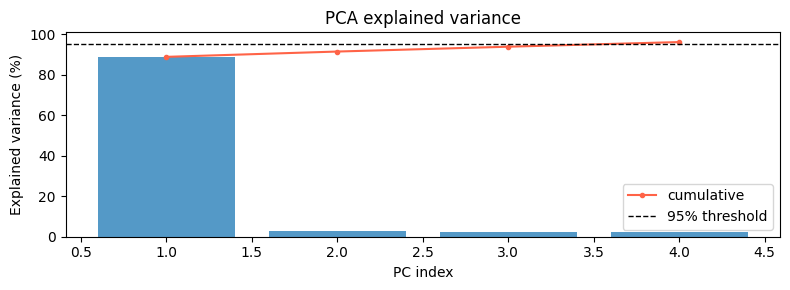

In [12]:
pca = PCA(n_components=VAR_THRESH, svd_solver='full')
pca.fit(feat_nom)

n_comp = pca.n_components_
var_exp = pca.explained_variance_ratio_.cumsum()
print(f'n_components = {n_comp}  (explains {var_exp[-1]:.3%} variance)')

# Explained variance plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_ * 100,
       color=NOMINAL_COLOR, alpha=0.8)
ax.plot(range(1, n_comp + 1), var_exp * 100,
        color='tomato', marker='o', ms=3, label='cumulative')
ax.axhline(VAR_THRESH * 100, color='black', ls='--', lw=1,
           label=f'{VAR_THRESH:.0%} threshold')
ax.set_xlabel('PC index'); ax.set_ylabel('Explained variance (%)')
ax.set_title('PCA explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [13]:
T2_tr,  Q_tr  = t2_q(feat_tr,       pca)
T2_val, Q_val = t2_q(feat_val,      pca)
T2_test_int, Q_test_int = t2_q(feat_test_int, pca)
T2_test, Q_test = t2_q(feat_test,   pca)

# Normalisation constants — fitted on nominal train windows only
# Used to put T² and Q on comparable scales before combining
T2_scale = np.percentile(T2_tr[nom_win_mask], 99)
Q_scale  = np.percentile(Q_tr[nom_win_mask],  99)

print(f'T2 scale (99th pct nominal): {T2_scale:.4g}')
print(f'Q  scale (99th pct nominal): {Q_scale:.4g}')

T2 scale (99th pct nominal): 29.39
Q  scale (99th pct nominal): 1.542


In [14]:
n_val_rows      = len(X_val)
n_test_int_rows = len(X_test_int)

# Pre-broadcast T² and Q; combined scores are computed per-alpha in grid search
scores_val_T2 = broadcast(T2_val, n_val_rows, WINDOW_SIZE, STRIDE)
scores_val_Q  = broadcast(Q_val,  n_val_rows, WINDOW_SIZE, STRIDE)

scores_test_int_T2 = broadcast(T2_test_int, n_test_int_rows, WINDOW_SIZE, STRIDE)
scores_test_int_Q  = broadcast(Q_test_int,  n_test_int_rows, WINDOW_SIZE, STRIDE)

## Threshold tuning — T², Q, combined

In [15]:
print(f'{"alpha":>6}  {"F0.5":>7}  {"threshold":>12}')
print('-' * 35)

best_alpha, best_score, best_thr = None, -1, None
best_scores_val = None

for alpha in ALPHA_GRID:
    if alpha == 1.0:
        sv = scores_val_T2
    elif alpha == 0.0:
        sv = scores_val_Q
    else:
        comb = alpha * T2_val / T2_scale + (1 - alpha) * Q_val / Q_scale
        sv   = broadcast(comb, n_val_rows, WINDOW_SIZE, STRIDE)

    res = tune_threshold(sv, y_val, metric_fn=esa_metric,
                         n_sweep=200,
                         lo_percentile=(0, 1.0),
                         hi_percentile=(1, 99.9))
    print(f'{alpha:>6.1f}  {res["score"]:>7.4f}  {res["threshold"]:>12.4g}')

    if res['score'] > best_score:
        best_alpha, best_score, best_thr = alpha, res['score'], res['threshold']
        best_scores_val = sv

print(f'\nBest: alpha={best_alpha}  F0.5={best_score:.4f}  thr={best_thr:.4g}')

 alpha     F0.5     threshold
-----------------------------------
   0.0   0.5986         6.841
   0.1   0.5986         4.547
   0.2   0.5986         4.714
   0.3   0.5986         4.999
   0.4   0.5986         5.208
   0.5   0.5986           5.4
   0.6   0.5986         5.542
   0.7   0.6428        0.6236
   0.8   0.6428        0.6093
   0.9   0.6428        0.6031
   1.0   0.6428         17.57

Best: alpha=0.7  F0.5=0.6428  thr=0.6236


In [16]:
y_pred_val = (best_scores_val > best_thr).astype(np.int8)
metrics = compute_all_metrics(y_val, y_pred_val)
print(f'\n── Validation metrics  (alpha={best_alpha}) ────────────────────')
for k, v in metrics.items():
    print(f'  {k:<28} {v}')


── Validation metrics  (alpha=0.7) ────────────────────
  event_f05                    0.645161
  event_f1                     0.457143
  event_f2                     0.353982
  event_precision              0.888889
  event_recall                 0.307692
  esa_f05                      0.642807
  esa_precision                0.883317
  esa_recall                   0.307692
  esa_tnr                      0.993732
  event_detection_rate         0.307692
  tp_events                    8
  n_events                     26
  fp_pred_events               1
  pa_f1                        0.598597
  pa_precision                 0.890038
  pa_recall                    0.450939
  row_precision                0.3776
  row_recall                   0.0338
  row_f1                       0.062046


In [17]:
# ── Internal test — threshold FROZEN from val tuning (no re-tuning) ───────────
if best_alpha == 1.0:
    best_scores_test_int = scores_test_int_T2
elif best_alpha == 0.0:
    best_scores_test_int = scores_test_int_Q
else:
    comb_ti = best_alpha * T2_test_int / T2_scale + (1 - best_alpha) * Q_test_int / Q_scale
    best_scores_test_int = broadcast(comb_ti, n_test_int_rows, WINDOW_SIZE, STRIDE)

y_pred_test_int = (best_scores_test_int > best_thr).astype(np.int8)
metrics_test_int = compute_all_metrics(y_test_int, y_pred_test_int)
print(f'── Internal test metrics  (alpha={best_alpha}) ───────────────────')
for k, v in metrics_test_int.items():
    print(f'  {k:<28} {v}')

── Internal test metrics  (alpha=0.7) ───────────────────
  event_f05                    0.681818
  event_f1                     0.55814
  event_f2                     0.472441
  event_precision              0.8
  event_recall                 0.428571
  esa_f05                      0.676571
  esa_precision                0.791002
  esa_recall                   0.428571
  esa_tnr                      0.988753
  event_detection_rate         0.428571
  tp_events                    12
  n_events                     28
  fp_pred_events               3
  pa_f1                        0.460153
  pa_precision                 0.778101
  pa_recall                    0.326669
  row_precision                0.208179
  row_recall                   0.024493
  row_f1                       0.043829


In [18]:
from sentinel.ml_logic.data import find_anomaly_segments

def split_tp_fn(y_true, y_pred):
    true_segs = find_anomaly_segments(y_true)
    pred_segs = find_anomaly_segments(y_pred)
    tp, fn = [], []
    for ts in true_segs:
        hit = any(ps['end'] >= ts['start'] and ps['start'] <= ts['end']
                  for ps in pred_segs)
        (tp if hit else fn).append(ts)
    return tp, fn


def plot_score_timeline(scores, y_true, thr, tp_events, fn_events, title=''):
    """Score over time with TP/FN event spans. Subsampled for speed."""
    step = max(1, len(scores) // 50_000)
    idx  = np.arange(0, len(scores), step)
    fig, ax = plt.subplots(figsize=(18, 3))
    ax.plot(idx, scores[idx], lw=0.4, color=NOMINAL_COLOR, label='anomaly score')
    ax.axhline(thr, color='black', lw=1.2, ls='--', label=f'threshold {thr:.4g}')
    for ev in tp_events:
        ax.axvspan(ev['start'], ev['end'], color='green', alpha=0.25, linewidth=0)
    for ev in fn_events:
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        ax.lines[0], ax.lines[1],
        Patch(color='green', alpha=0.4, label=f'TP events ({len(tp_events)})'),
        Patch(color=ANOMALY_COLOR, alpha=0.4, label=f'FN events ({len(fn_events)})'),
    ], fontsize=8, loc='upper right')
    ax.set_xlabel('Val row index'); ax.set_ylabel('Score')
    ax.set_title(title or 'Score timeline')
    plt.tight_layout(); plt.show()


def plot_score_dist(scores, y_true, thr):
    """Score histogram: nominal vs anomaly."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(scores[y_true == 0], bins=300, density=True,
            color=NOMINAL_COLOR, alpha=0.6, label='nominal')
    ax.hist(scores[y_true == 1], bins=80, density=True,
            color=ANOMALY_COLOR, alpha=0.7, label='anomaly')
    ax.axvline(thr, color='black', ls='--', lw=1.2, label=f'threshold {thr:.4g}')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.set_title('Score distribution: nominal vs anomaly')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_duration_hist(tp_events, fn_events):
    """Event duration distribution: TP (caught) vs FN (missed)."""
    tp_len = [e['length'] for e in tp_events]
    fn_len = [e['length'] for e in fn_events]
    bins   = np.logspace(0, 6, 50)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3), sharey=True)
    for ax, lens, color, label in [
        (axes[0], tp_len, 'green',     f'TP — caught ({len(tp_len)})'),
        (axes[1], fn_len, ANOMALY_COLOR, f'FN — missed ({len(fn_len)})'),
    ]:
        if lens:
            ax.hist(lens, bins=bins, color=color, alpha=0.75)
        ax.set_xscale('log'); ax.set_xlabel('Event length (rows)')
        ax.set_ylabel('Count'); ax.set_title(label)
    plt.suptitle('Event duration distribution (log scale)', y=1.02)
    plt.tight_layout(); plt.show()

    if tp_len and fn_len:
        print(f'TP median length: {int(np.median(tp_len)):,}  '
              f'| FN median length: {int(np.median(fn_len)):,}')


def plot_missed_zoom(fn_events, scores, y_true, X_val_df, channels, thr,
                     n_show=3, margin=500):
    """Zoom on up to n_show missed events: raw channels + score."""
    show = fn_events[:n_show]
    if not show:
        print('No missed events to display.'); return
    fig, axes = plt.subplots(len(show), 1, figsize=(15, 4.5 * len(show)),
                             squeeze=False)
    for ax_row, ev in zip(axes, show):
        ax = ax_row[0]
        s  = max(0, ev['start'] - margin)
        e  = min(len(scores) - 1, ev['end'] + margin)
        xs = np.arange(s, e + 1)
        for ch in channels:
            ax.plot(xs, X_val_df[ch].values[s: e + 1], lw=0.5, alpha=0.7, label=ch)
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
        ax2 = ax.twinx()
        ax2.plot(xs, scores[s: e + 1], color='orange', lw=0.9, alpha=0.8, label='score')
        ax2.axhline(thr, color='black', ls='--', lw=1, alpha=0.7)
        ax2.set_ylabel('Score', color='orange')
        ax.set_title(f"Missed event  start={ev['start']:,}  "
                     f"end={ev['end']:,}  len={ev['length']:,}")
        ax.legend(fontsize=7, loc='upper left', ncol=len(channels))
    plt.tight_layout(); plt.show()

## Viz 1 — Score timeline

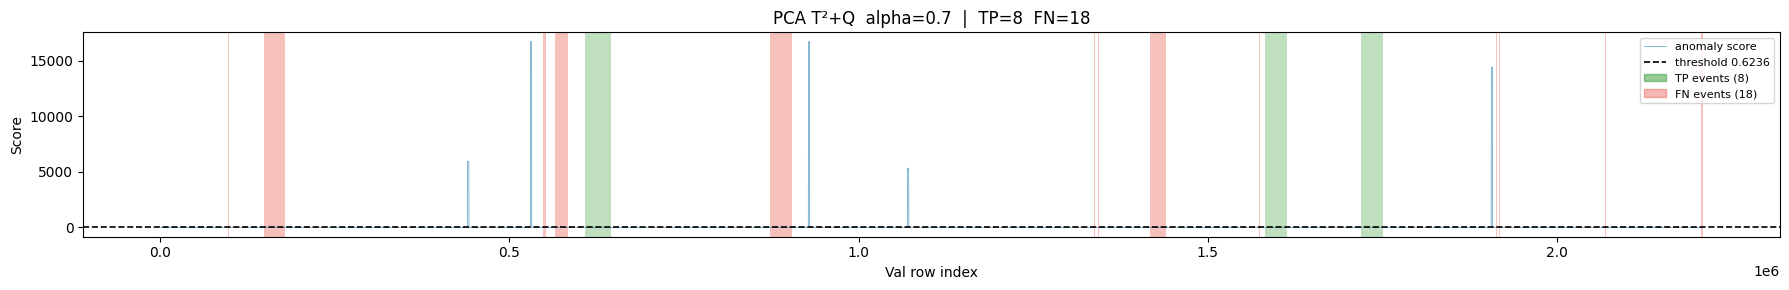

In [19]:
tp_events, fn_events = split_tp_fn(y_val, y_pred_val)
plot_score_timeline(
    best_scores_val, y_val, best_thr, tp_events, fn_events,
    title=f'PCA T²+Q  alpha={best_alpha}  |  '
          f'TP={len(tp_events)}  FN={len(fn_events)}')

## Viz 2 — Score distribution

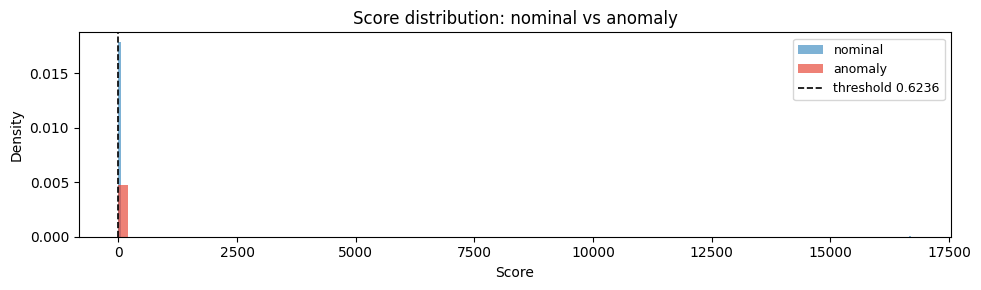

In [20]:
plot_score_dist(best_scores_val, y_val, best_thr)

## Viz 3 — Event duration: TP vs FN

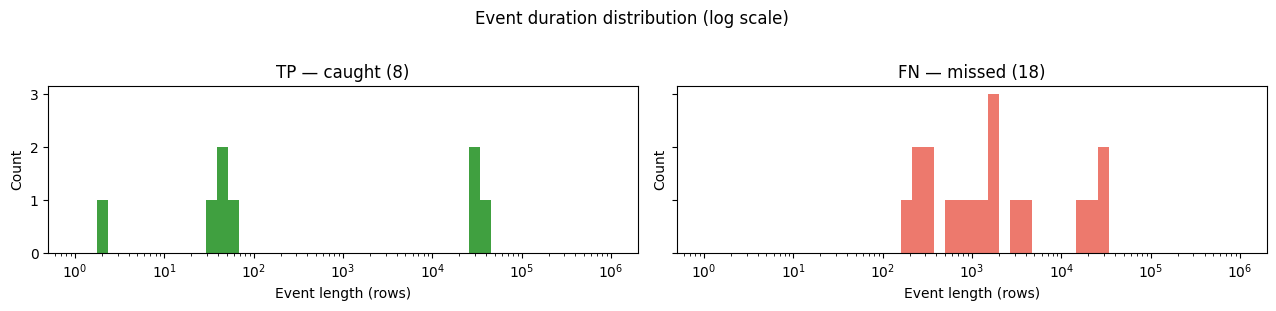

TP median length: 54  | FN median length: 1,502


In [21]:
plot_duration_hist(tp_events, fn_events)

## Viz 4 — Zoom on missed events

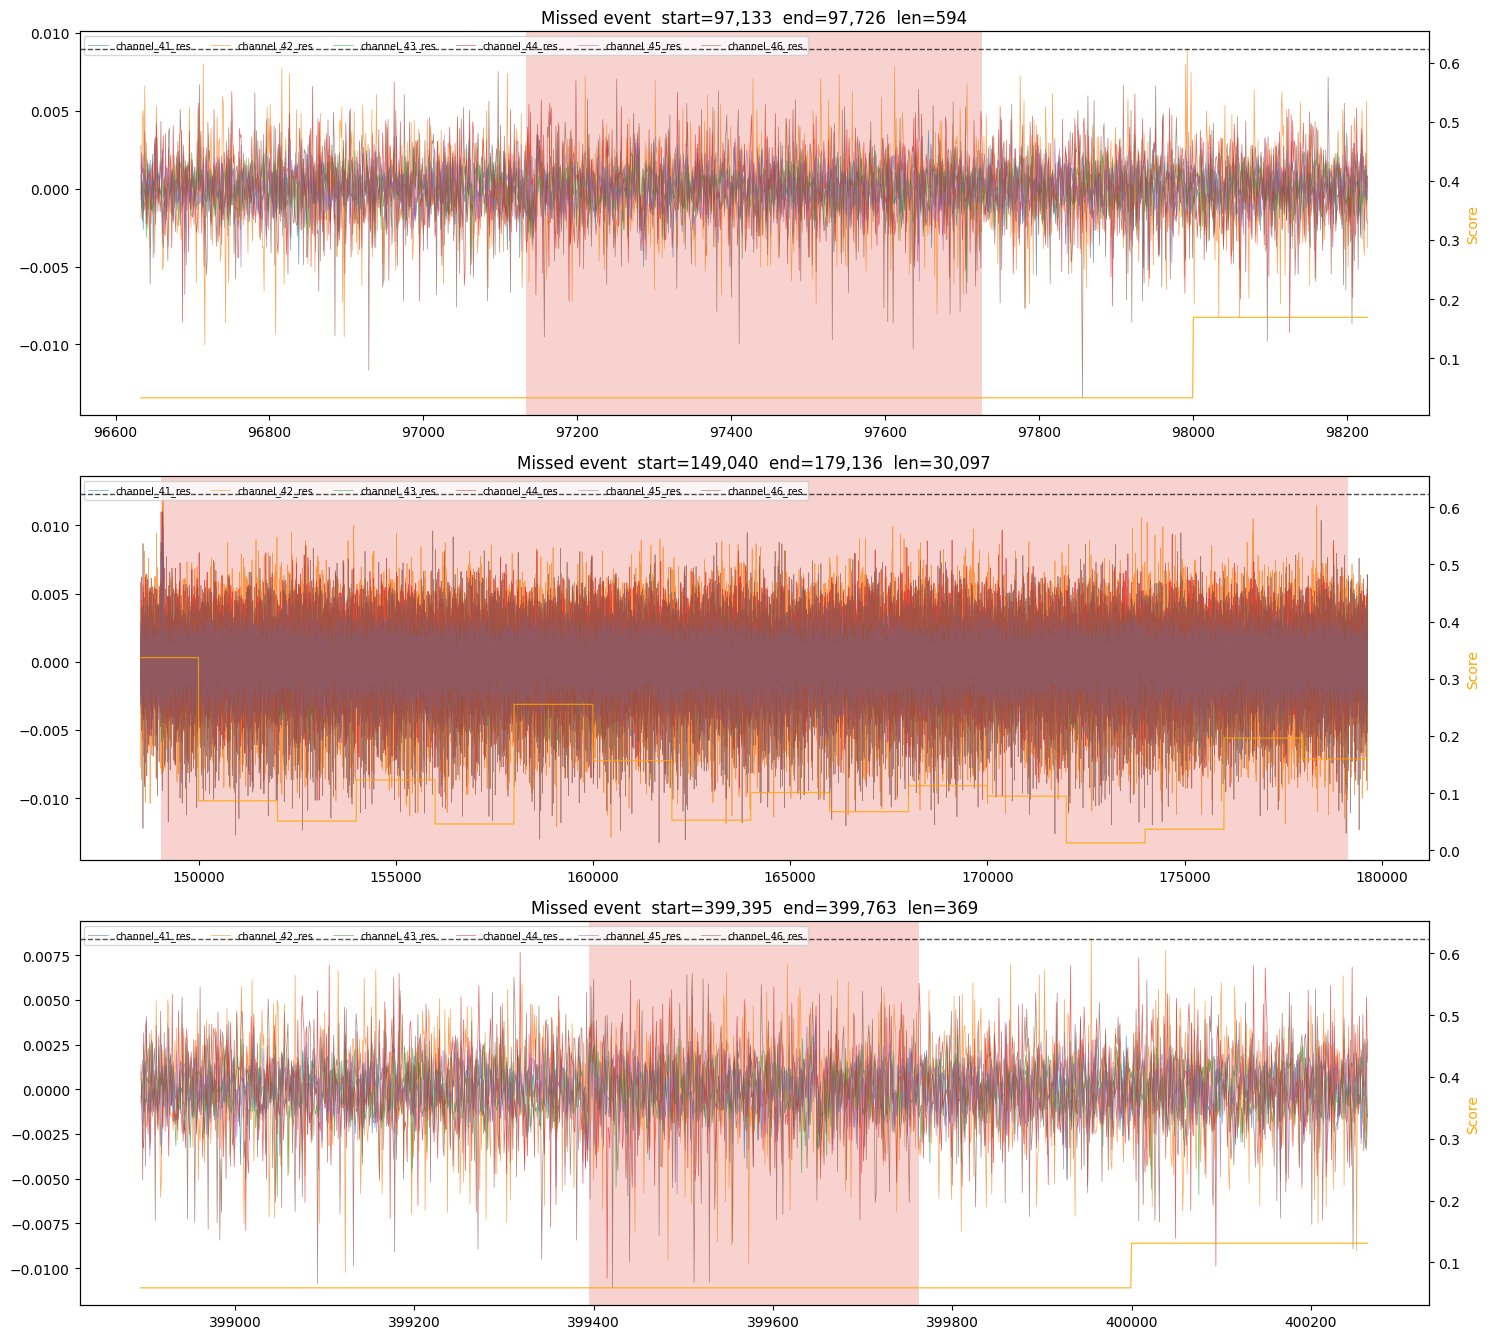

In [22]:
plot_missed_zoom(fn_events, best_scores_val, y_val, X_val, CHANNELS, best_thr)

## Test inference & submission

In [23]:
if best_alpha == 1.0:
    best_scores_test = broadcast(T2_test, len(test), WINDOW_SIZE, STRIDE)
elif best_alpha == 0.0:
    best_scores_test = broadcast(Q_test, len(test), WINDOW_SIZE, STRIDE)
else:
    comb_t = best_alpha * T2_test / T2_scale + (1 - best_alpha) * Q_test / Q_scale
    best_scores_test = broadcast(comb_t, len(test), WINDOW_SIZE, STRIDE)

y_pred_test = (best_scores_test > best_thr).astype(int)
sub = pd.DataFrame({'id': test.index, 'is_anomaly': y_pred_test})
out_path = SUB_DIR / 'ek_pca_t2_res.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path}')
print(f'Predicted anomaly rate: {y_pred_test.mean():.4%}')

Saved submissions/ek_pca_t2_res.csv
Predicted anomaly rate: 1.9184%
